# 静息态 EEG 频域分析 - 多被试批量处理

批量处理所有被试，进行组平均和组水平统计

In [42]:
# 导入必要的库
import os
import os.path as op
import mne
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd

# 设置中文字体（消除中文显示警告）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 提前触发 MNE 的 lazy loading，避免在循环中出错
# 这会在导入阶段就触发任何潜在的文档生成错误
try:
    from mne import read_epochs
except:
    pass




In [43]:
# 设置路径和被试列表
sub_ids = ['001', '021', '022', '024', '047', '049', '051', '071', '072', '073', '076', '092']
data_path = r'..\..\preprocessing\data\6epoch_clean\\'
save_path = r'.\results\group\\'
fig_path = r'.\figures\group\\'

# 创建输出目录
os.makedirs(save_path, exist_ok=True)
os.makedirs(fig_path, exist_ok=True)

print(f'将处理 {len(sub_ids)} 个被试')

将处理 12 个被试


In [44]:
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """计算SNR谱"""  
    averaging_kernel = np.concatenate((
        np.ones(noise_n_neighbor_freqs),
        np.zeros(2 * noise_skip_neighbor_freqs + 1),
        np.ones(noise_n_neighbor_freqs)))
    averaging_kernel /= averaging_kernel.sum()
    
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"),
        axis=-1, arr=psd
    )
    
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)
    
    return psd / mean_noise

## 批量处理所有被试

In [45]:
# 初始化存储列表
list_psds = []
list_snrs_mean = []
list_band_powers = []
list_relative_powers = []

# 定义频段
bands = {"Delta": (1, 4), "Theta": (4, 8), "Alpha": (8, 13), "Beta": (13, 30), "Gamma": (30, 40)}

# 初始化全局变量（将在第一个被试处理时设置）
freqs = None
freq_range = None

success_count = 0
failed_list = []

print(f"开始批量处理 {len(sub_ids)} 个被试...\n")

开始批量处理 12 个被试...



In [46]:
# 批量处理主循环
TARGET_SFREQ = 500  # 目标采样率
TARGET_DURATION = 10.0  # 目标epoch时长（秒）
TARGET_SAMPLES = int(TARGET_SFREQ * TARGET_DURATION)  # 5000 采样点

for sub_id in tqdm(sub_ids, desc="处理被试"):
    try:
        # 1. 读取epochs
        fname = op.join(data_path, sub_id + "-epo.fif")
        epochs = mne.read_epochs(fname, preload=True, verbose=False)
        
        # 检查采样率，如果不是500Hz则重采样
        if epochs.info['sfreq'] != TARGET_SFREQ:
            print(f"\n[{sub_id}] 重采样: {epochs.info['sfreq']} -> {TARGET_SFREQ} Hz")
            epochs = epochs.resample(TARGET_SFREQ)
        
        # 统一epoch长度：截取到目标采样点数
        n_times = len(epochs.times)
        if n_times != TARGET_SAMPLES:
            # 计算需要的tmax，确保得到exactly TARGET_SAMPLES个点
            tmax = (TARGET_SAMPLES - 1) / TARGET_SFREQ
            epochs = epochs.crop(tmin=0, tmax=tmax)
            print(f"\n[{sub_id}] 统一epoch长度: {n_times} -> {len(epochs.times)} 采样点")
        
        # 2. 计算PSD - 自动适应epoch长度
        tmin, tmax_psd, fmin, fmax = 0., None, 1., 40.  # tmax=None 使用整个epoch
        
        # 根据epoch长度自动设置n_fft
        n_times = len(epochs.times)
        sfreq = epochs.info['sfreq']
        n_fft = n_times  # 使用实际采样点数
        
        psd = epochs.compute_psd(
            method="welch", fmin=fmin, fmax=fmax,
            tmin=tmin, tmax=tmax_psd, n_fft=n_fft,
            n_overlap=0, verbose=False)
        psds_all = psd.get_data()
        psds = psds_all.mean(axis=0)
        
        # 保存频率信息（第一个被试）
        if freqs is None:
            freqs = psd.freqs
            print(f"\n基准频率点数: {len(freqs)}")
        
        # 验证频率点数一致
        if len(psd.freqs) != len(freqs):
            print(f"\n[{sub_id}] 警告: 频率点数不一致 ({len(psd.freqs)} vs {len(freqs)})")
            continue
        
        list_psds.append(psds)
        
        # 3. 计算SNR
        snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=0)
        
        # 保存频率范围（第一个被试）
        if freq_range is None:
            # 使用更安全的索引方式
            start_idx = np.where(freqs >= 1.0)[0][0]
            end_idx = np.where(freqs <= fmax - 1)[0][-1]
            freq_range = range(start_idx, end_idx + 1)
        
        snr_mean = snrs.mean(axis=0)[freq_range]
        list_snrs_mean.append(snr_mean)
        
        # 4. 计算频段功率
        band_powers = {}
        for band_name, (fmin_band, fmax_band) in bands.items():
            freq_idx = np.where((freqs >= fmin_band) & (freqs <= fmax_band))[0]
            band_power = psds[:, freq_idx].mean(axis=1)
            band_powers[band_name] = band_power
        list_band_powers.append(band_powers)
        
        # 5. 计算相对功率
        total_power = sum(band_powers.values())
        relative_powers = {k: (v / total_power) * 100 for k, v in band_powers.items()}
        list_relative_powers.append(relative_powers)
        
        success_count += 1
        
    except Exception as e:
        import traceback
        print(f"\n[{sub_id}] 处理失败:")
        print(f"  错误类型: {type(e).__name__}")
        print(f"  错误信息: {str(e)}")
        failed_list.append(sub_id)

print(f"\n批量处理完成！")
print(f"成功: {success_count}/{len(sub_ids)}")
if failed_list:
    print(f"失败列表: {failed_list}")

处理被试:   0%|          | 0/12 [00:00<?, ?it/s]


[001] 重采样: 1000.0 -> 500 Hz

基准频率点数: 391


处理被试:   8%|▊         | 1/12 [00:00<00:10,  1.08it/s]


[021] 重采样: 1000.0 -> 500 Hz


处理被试:  17%|█▋        | 2/12 [00:02<00:11,  1.10s/it]

...


[076] 统一epoch长度: 5001 -> 5000 采样点


处理被试:  92%|█████████▏| 11/12 [00:08<00:00,  1.36it/s]


[092] 重采样: 1000.0 -> 500 Hz


处理被试: 100%|██████████| 12/12 [00:09<00:00,  1.31it/s]



批量处理完成！
成功: 12/12


## 组平均分析

In [47]:
# 组平均计算
# 1. PSD组平均
psds_array = np.array(list_psds)
psds_group = psds_array.mean(axis=0)
psds_group_std = psds_array.std(axis=0)
print(f"PSD组平均 shape: {psds_group.shape}")

# 2. SNR组平均
snr_group_mean = np.array(list_snrs_mean).mean(axis=0)
snr_group_std = np.array(list_snrs_mean).std(axis=0)
freqs_snr = freqs[freq_range]
print(f"SNR组平均 shape: {snr_group_mean.shape}")

# 3. 频段功率组平均
band_powers_group = {}
band_powers_group_std = {}
for band_name in bands.keys():
    band_data = np.array([bp[band_name] for bp in list_band_powers])
    band_powers_group[band_name] = band_data.mean(axis=0)
    band_powers_group_std[band_name] = band_data.std(axis=0)

# 4. 相对功率组平均
relative_powers_group = {}
for band_name in bands.keys():
    rel_data = np.array([rp[band_name] for rp in list_relative_powers])
    relative_powers_group[band_name] = rel_data.mean(axis=0)

print("组平均计算完成")

PSD组平均 shape: (59, 391)
SNR组平均 shape: (381,)
组平均计算完成


## 组平均可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30828\1610184661.py:14: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30828\1610184661.py:15: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.savefig(f"{fig_path}group_psd.png", dpi=150, bbox_inches="tight")
d:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


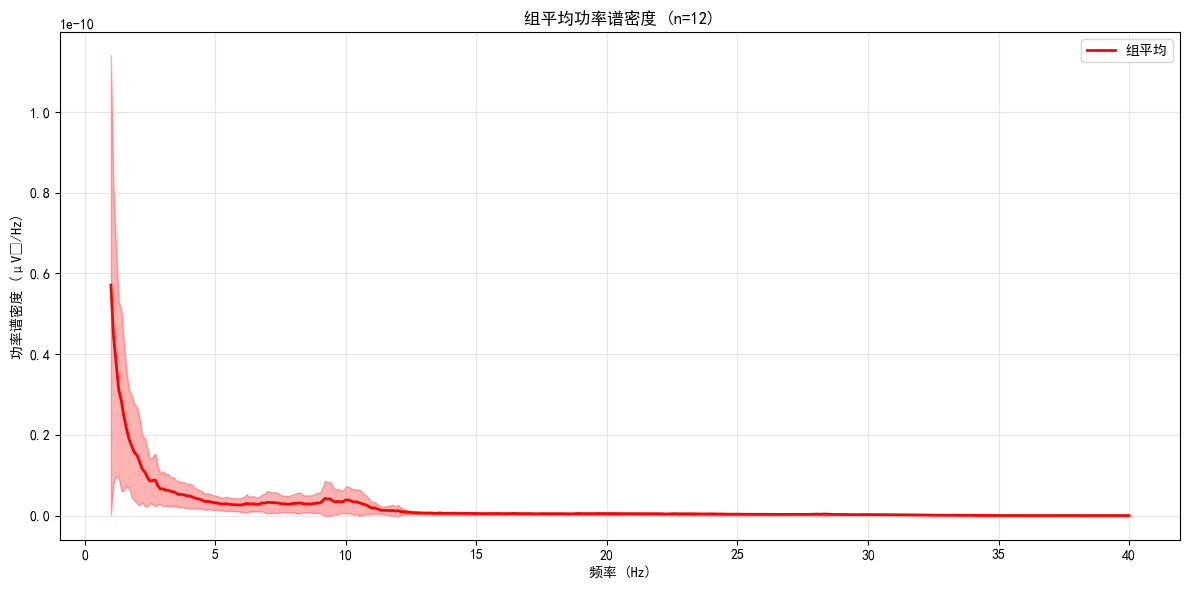

✓ 已保存: .\figures\group\\group_psd.png


In [48]:
# 可视化PSD组平均
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 6))
psd_mean = psds_group.mean(axis=0)
psd_std = psds_group_std.mean(axis=0)
ax.plot(freqs, psd_mean, color="red", linewidth=2, label="组平均")
ax.fill_between(freqs, psd_mean - psd_std, psd_mean + psd_std, alpha=0.3, color="red")
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("功率谱密度 (μV²/Hz)")
ax.set_title(f"组平均功率谱密度 (n={success_count})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{fig_path}group_psd.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ 已保存: {fig_path}group_psd.png")

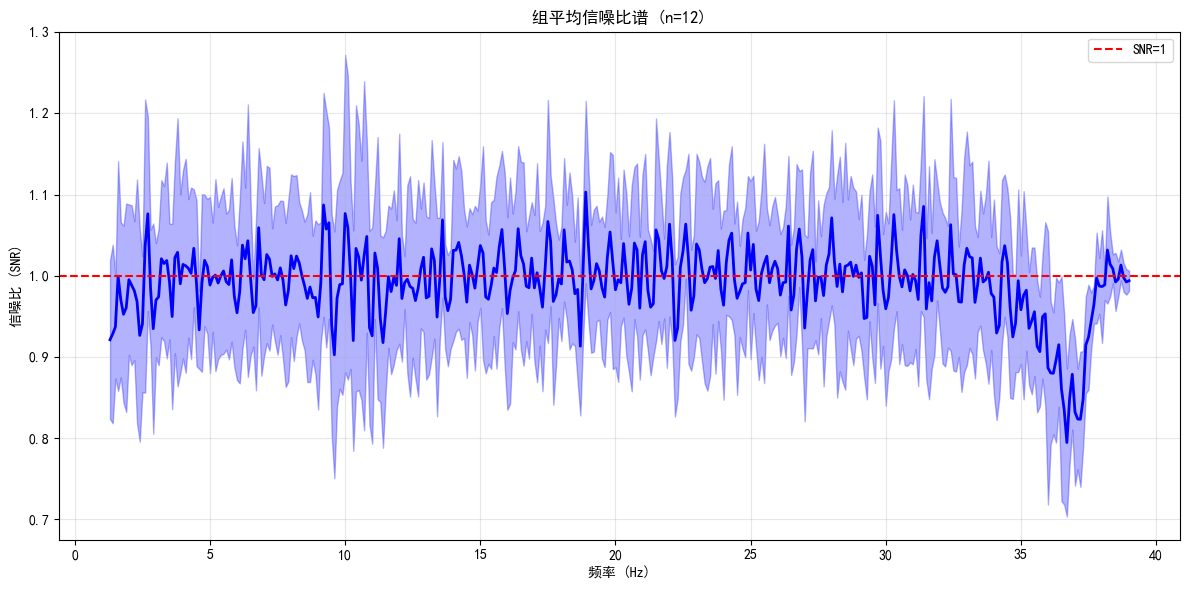

✓ 已保存: .\figures\group\\group_snr.png


In [49]:
# 可视化SNR组平均
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs_snr, snr_group_mean, color="blue", linewidth=2)
ax.fill_between(freqs_snr, snr_group_mean - snr_group_std, 
                snr_group_mean + snr_group_std, alpha=0.3, color="blue")
ax.axhline(y=1, color="red", linestyle="--", label="SNR=1")
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("信噪比 (SNR)")
ax.set_title(f"组平均信噪比谱 (n={success_count})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{fig_path}group_snr.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ 已保存: {fig_path}group_snr.png")

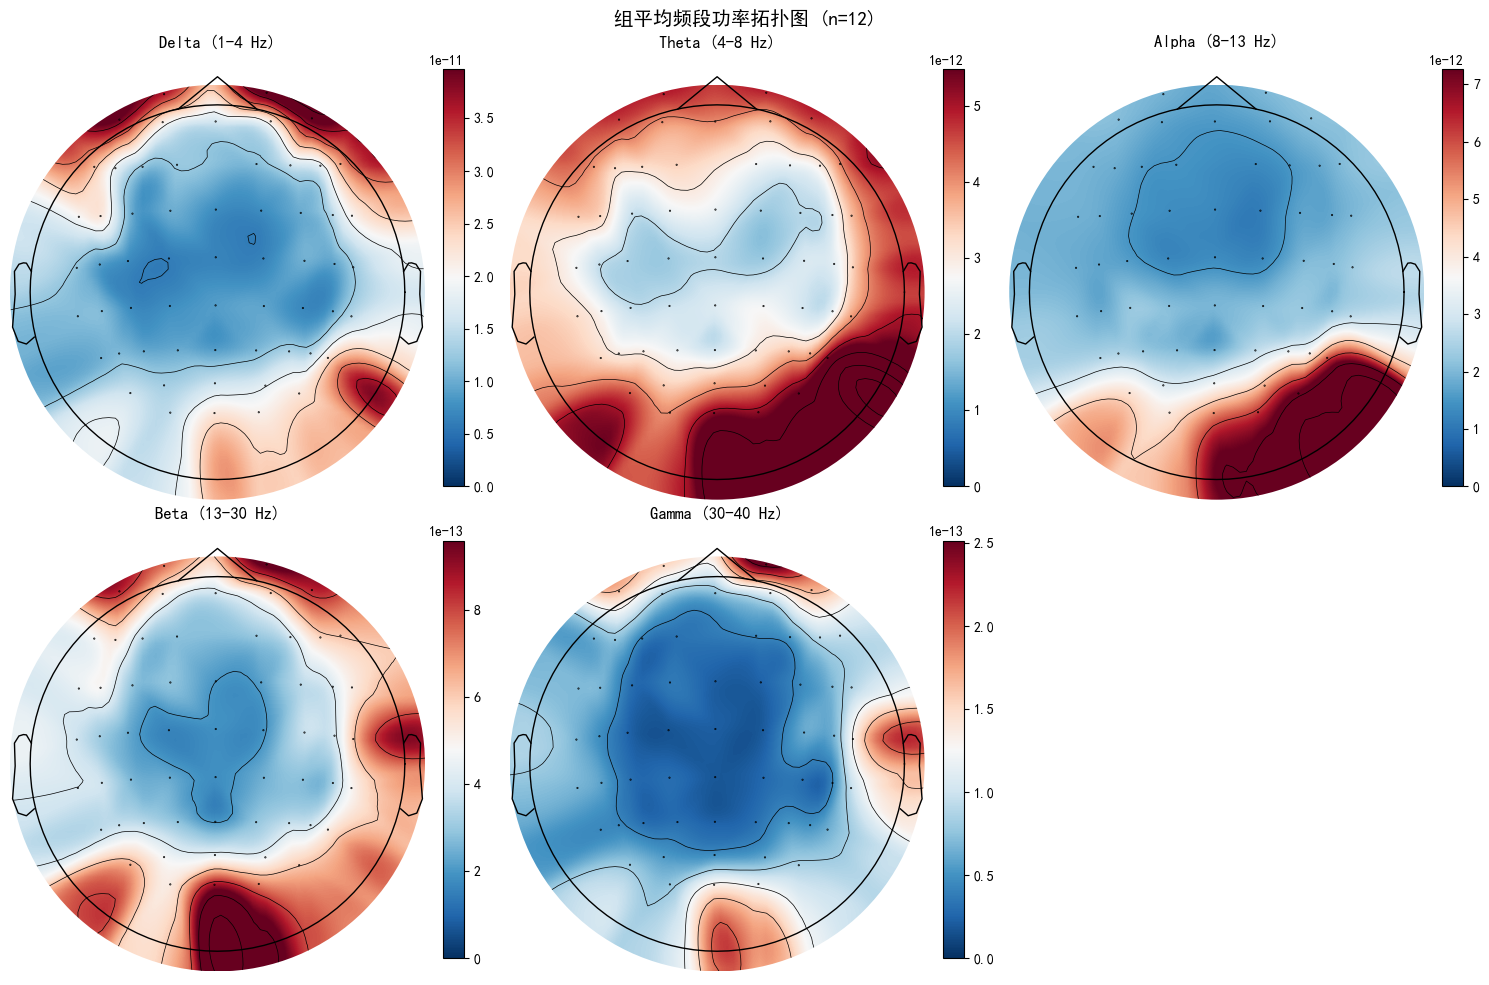

✓ 已保存: .\figures\group\\group_band_powers.png


In [50]:
# 可视化频段功率组平均拓扑图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (band_name, band_power) in enumerate(band_powers_group.items()):
    if idx < len(axes):
        im, _ = mne.viz.plot_topomap(
            band_power, epochs.info, axes=axes[idx],
            show=False, cmap="RdBu_r"
        )
        axes[idx].set_title(f"{band_name} ({bands[band_name][0]}-{bands[band_name][1]} Hz)")
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

axes[-1].axis("off")
plt.suptitle(f"组平均频段功率拓扑图 (n={success_count})", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{fig_path}group_band_powers.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ 已保存: {fig_path}group_band_powers.png")

## 描述性统计

In [51]:
# 计算各频段功率的描述性统计
stats_data = []
for band_name in bands.keys():
    band_data = np.array([bp[band_name] for bp in list_band_powers])
    # 跨被试和通道平均
    band_mean = band_data.mean()
    band_std = band_data.std()
    stats_data.append({
        "频段": band_name,
        "频率范围": f"{bands[band_name][0]}-{bands[band_name][1]} Hz",
        "平均功率": f"{band_mean:.2e}",
        "标准差": f"{band_std:.2e}"
    })

stats_df = pd.DataFrame(stats_data)
print("频段功率描述性统计:")
print(stats_df.to_string(index=False))

频段功率描述性统计:
   频段     频率范围     平均功率      标准差
Delta   1-4 Hz 1.48e-11 1.65e-11
Theta   4-8 Hz 3.18e-12 2.14e-12
Alpha  8-13 Hz 2.38e-12 2.12e-12
 Beta 13-30 Hz 4.17e-13 3.50e-13
Gamma 30-40 Hz 6.33e-14 7.25e-14


## 保存组分析结果

In [52]:
# 保存组分析结果
group_results = {
    "n_subjects": success_count,
    "subject_ids": [sid for sid in sub_ids if sid not in failed_list],
    "psd_group": {"mean": psds_group, "std": psds_group_std, "freqs": freqs},
    "snr_group": {"mean": snr_group_mean, "std": snr_group_std, "freqs": freqs_snr},
    "band_powers_group": {"mean": band_powers_group, "std": band_powers_group_std},
    "relative_powers_group": relative_powers_group,
    "bands": bands,
    "statistics": stats_df.to_dict()
}

result_file = f"{save_path}group_frequency_results.pkl"
with open(result_file, "wb") as f:
    pickle.dump(group_results, f)

print(f"已保存组分析结果: {result_file}")
print(f"结果包含:")
print(f"  - 被试数: {success_count}")
print(f"  - PSD组平均: {psds_group.shape}")
print(f"  - SNR组平均: {snr_group_mean.shape}")
print(f"  - 频段功率: {len(band_powers_group)} 个频段")
print(f"  - 描述性统计表")

已保存组分析结果: .\results\group\\group_frequency_results.pkl
结果包含:
  - 被试数: 12
  - PSD组平均: (59, 391)
  - SNR组平均: (381,)
  - 频段功率: 5 个频段
  - 描述性统计表
